In [1]:
from orderbike import metrics
import osmnx as ox
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
from orderbike.utils import auc_from_metrics_dict, get_auc
import pandas as pd
import json

/Users/clse/miniforge3/envs/orderbike/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
folderoots = "../data/processed/paris_simplified_results"
G = ox.load_graphml(folderoots + "/paris_cleaned_multigraph.graphml")

In [3]:
gdf_edges = ox.graph_to_gdfs(G, edges=True, nodes=False)

In [ ]:
gdf_edges

In [118]:
dict_simp = {
    "No": "Not built yet",
    "2021 and before": "Built before Plan Vélo",
    "2023-05-17": "Built during Plan Vélo",
    "2023-10-01": "Built during Plan Vélo",
    "2024-01-15": "Built during Plan Vélo",
    "2024-04-04": "Built during Plan Vélo",
    "2024-08-22": "Built during Plan Vélo",
    "2024-12-22": "Built during Plan Vélo",
    "2025-06-02": "Built during Plan Vélo",
}

In [119]:
gdf_edges["built_simple"] = gdf_edges["built"].map(dict_simp)

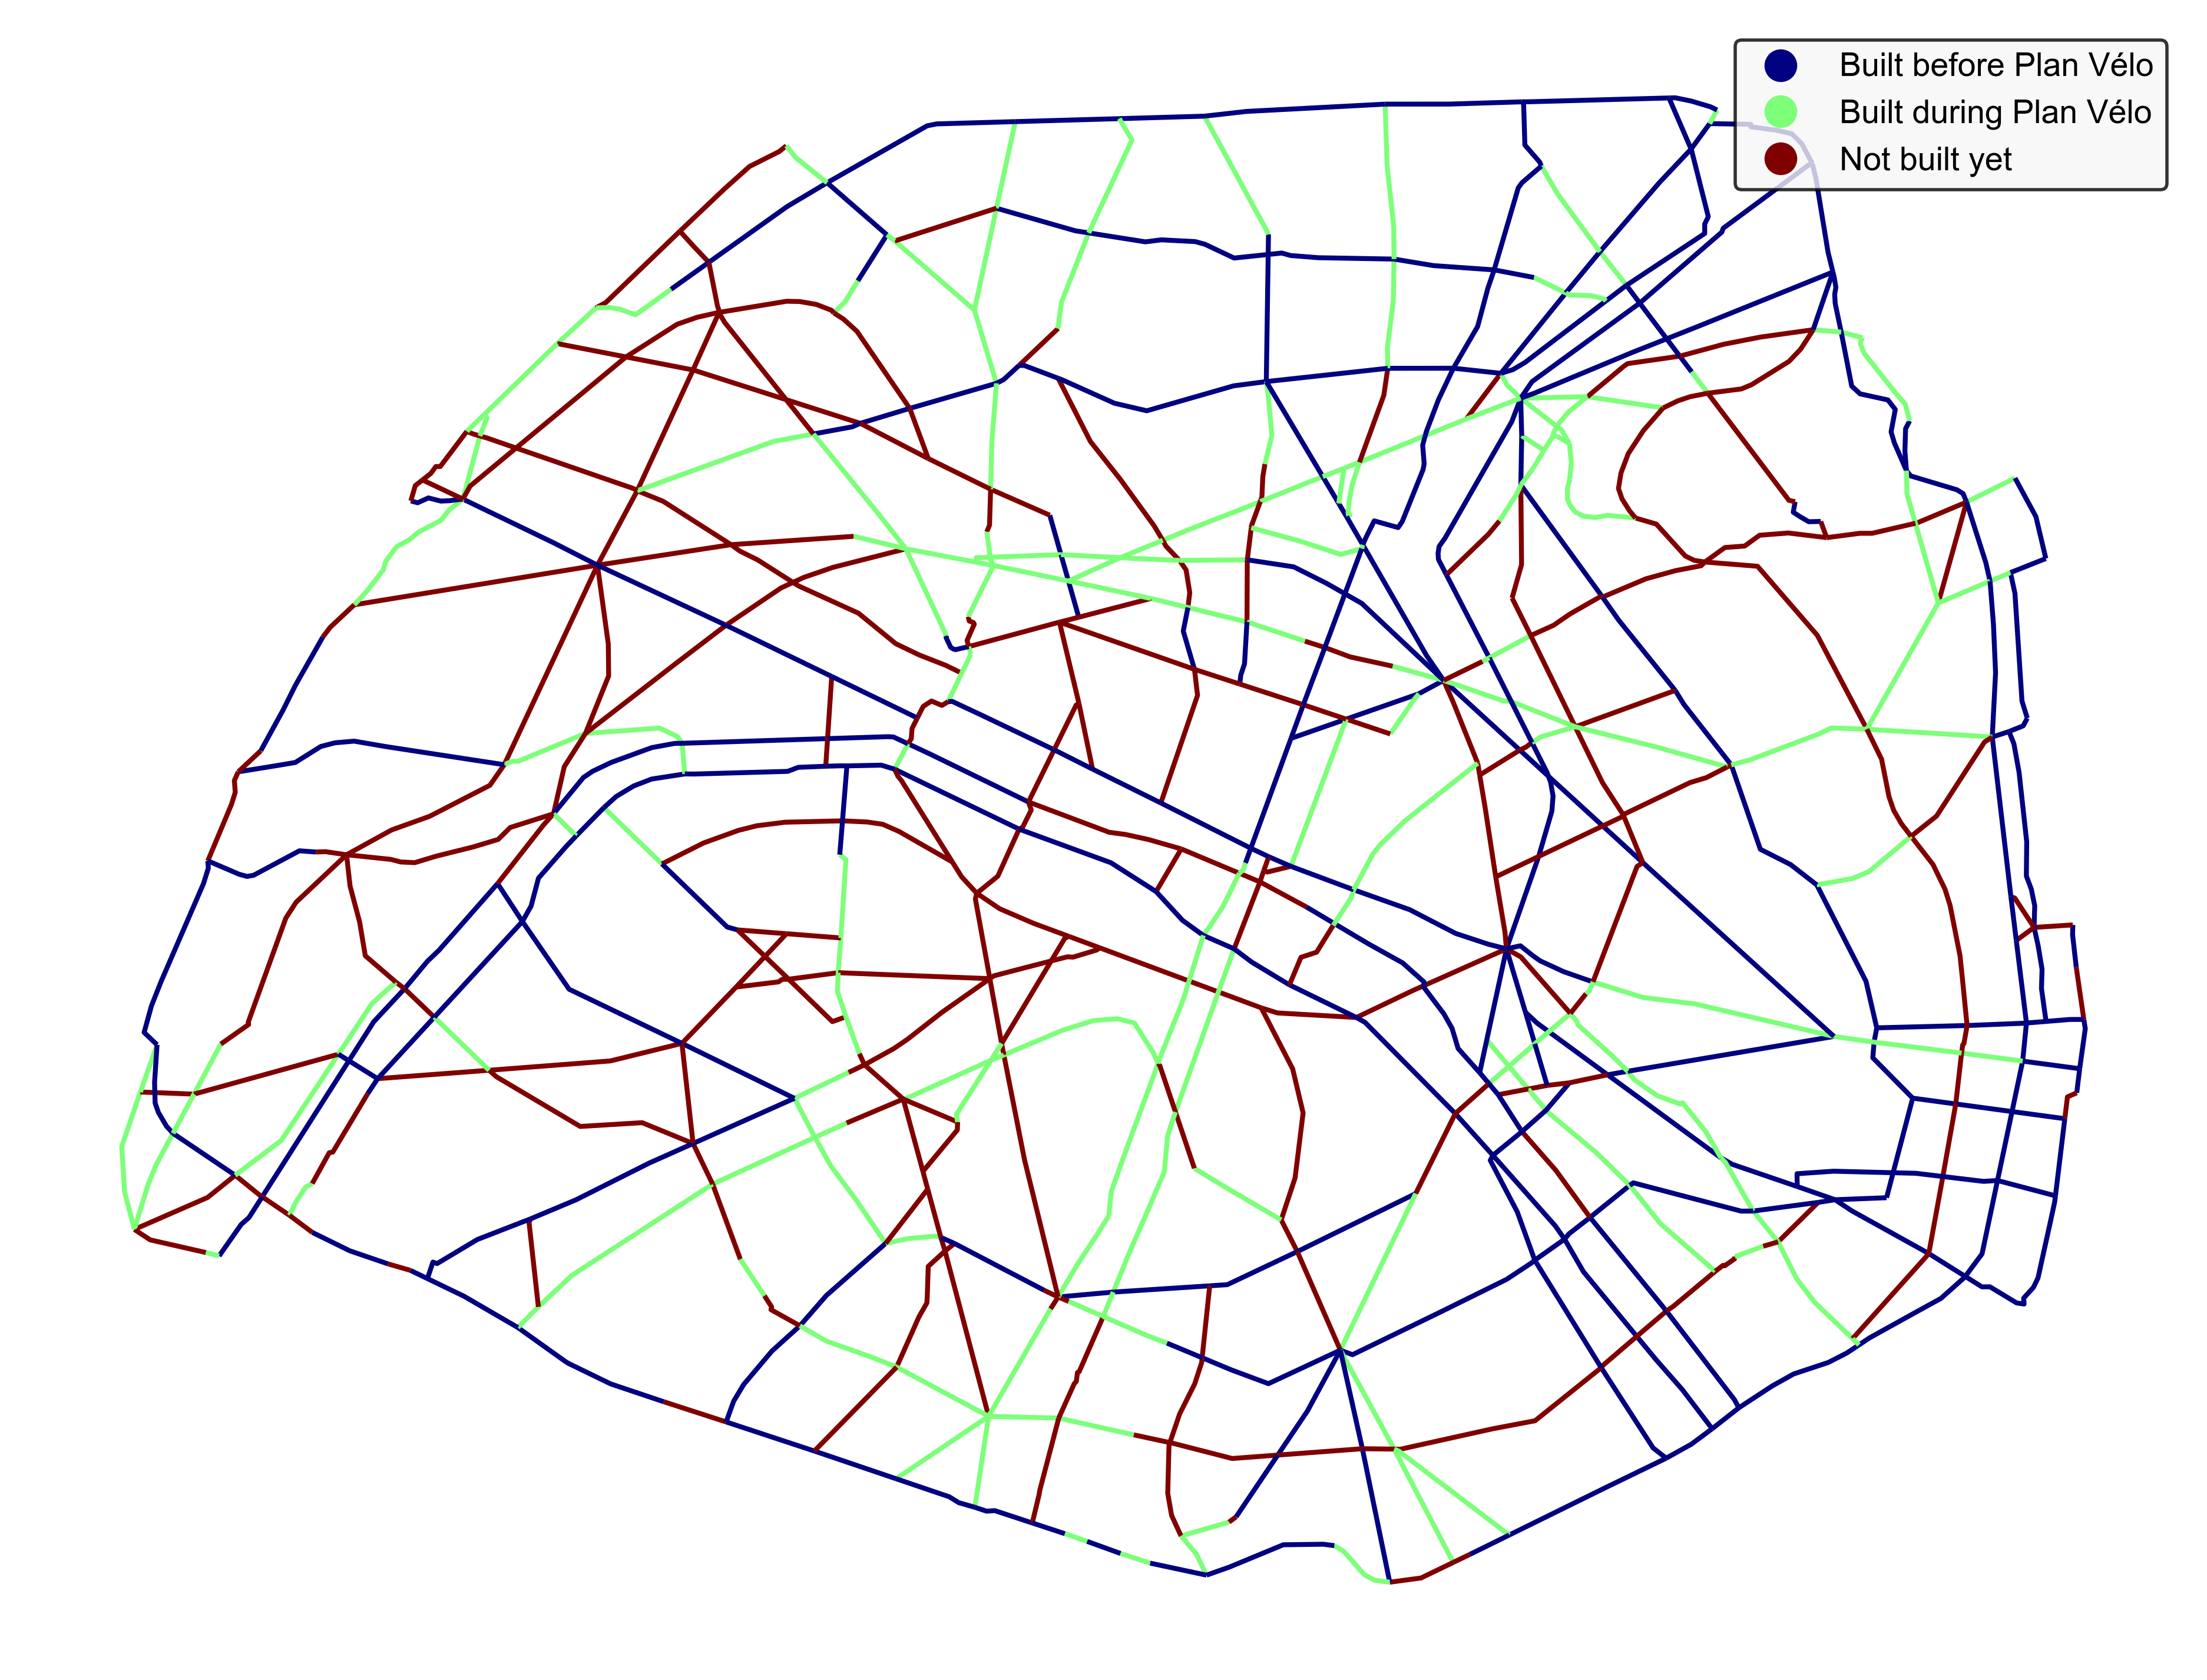

In [128]:
fig, ax = plt.subplots(figsize=(16, 9))
gdf_edges.plot(ax=ax, column="built_simple", legend=True, cmap="jet")
# Source - https://stackoverflow.com/a/2176591
# Posted by Ofri Raviv, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-13, License - CC BY-SA 3.0
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)
ax.spines.left.set_visible(False)
ax.spines.bottom.set_visible(False)

In [113]:
datetimes = sorted(list(set(gdf_edges["built"].values)))
num_edges = []
tot_length = []
directness = []
coverage = []
num_comp = []
for idx, time in enumerate(datetimes[:-1]):
    print(time)
    H = G.edge_subgraph(
        [e for e in G.edges if G.edges[e]["built"] in datetimes[: idx + 1]]
    )
    num_edges.append(len(H.edges))
    tot_length.append(sum([H.edges[e]["length"] for e in H.edges]))
    directness.append(metrics.directness(H))
    coverage.append(metrics.coverage(H, 400))
    num_comp.append(nx.number_connected_components(H))
closeness = nx.closeness_centrality(G, distance="length")
edge_closeness = {}
for edge in G.edges:
    edge_closeness[edge] = (closeness[edge[0]] + closeness[edge[1]]) / 2
init_edge = [tuple(max(edge_closeness, key=edge_closeness.get))]
G_init = G.edge_subgraph(init_edge)
num_edges = [len(G_init.edges)] + num_edges
tot_length = [sum([G_init.edges[e]["length"] for e in G_init.edges])] + tot_length
directness = [metrics.directness(G_init)] + directness
coverage = [metrics.coverage(G_init, 400)] + coverage
num_comp = [nx.number_connected_components(G_init)] + num_comp
num_edges.append(len(G.edges))
tot_length.append(sum([G.edges[e]["length"] for e in G.edges]))
directness.append(metrics.directness(G))
coverage.append(metrics.coverage(G, 400))
num_comp.append(nx.number_connected_components(G))

2021 and before
2023-05-17
2023-10-01
2024-01-15
2024-04-04
2024-08-22
2024-12-22
2025-06-02


In [109]:
num_comp

[1, 20, 20, 17, 17, 16, 9, 8, 9, 1]

In [85]:
full_opti_dir = pd.read_json(
    "../data/processed/paris_simplified_results/Nothing/directness_additive_connected/metrics_growth.json"
)

In [86]:
full_opti_cov = pd.read_json(
    "../data/processed/paris_simplified_results/Nothing/coverage_additive_connected/metrics_growth.json"
)

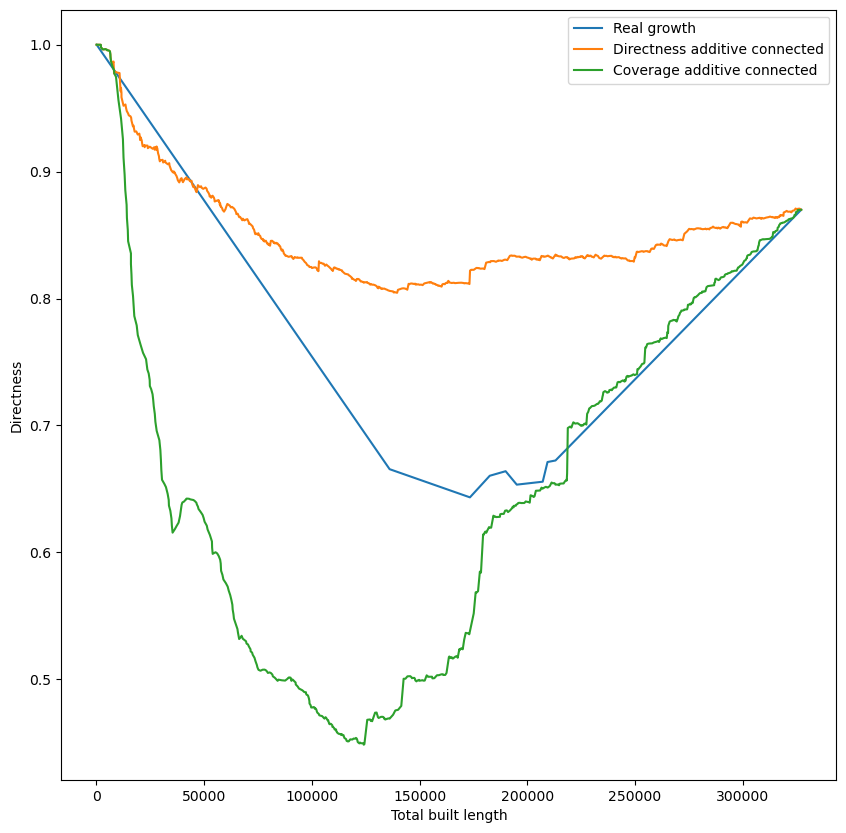

In [87]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(tot_length, directness, label="Real growth")
ax.plot(
    full_opti_dir["xx"].values,
    full_opti_dir["directness"].values,
    label="Directness additive connected",
)
ax.plot(
    full_opti_cov["xx"].values,
    full_opti_cov["directness"].values,
    label="Coverage additive connected",
)
ax.set_xlabel("Total built length")
ax.set_ylabel("Directness")
ax.legend()

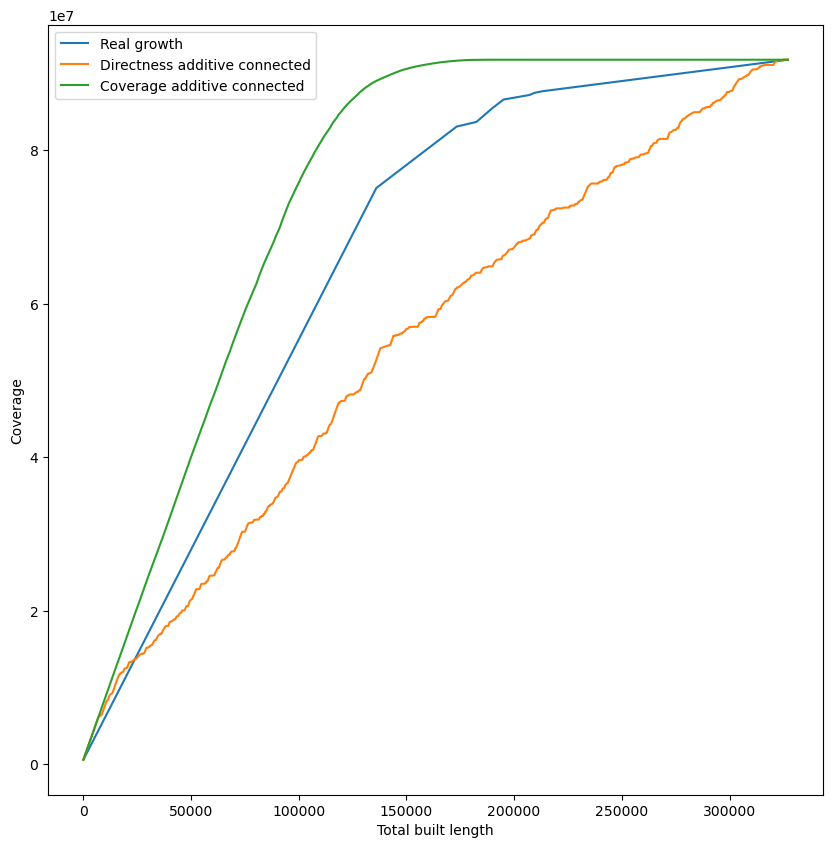

In [89]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(tot_length, coverage, label="Real growth")
ax.plot(
    full_opti_dir["xx"].values,
    full_opti_dir["coverage"].values,
    label="Directness additive connected",
)
ax.plot(
    full_opti_cov["xx"].values,
    full_opti_cov["coverage"].values,
    label="Coverage additive connected",
)
ax.set_xlabel("Total built length")
ax.set_ylabel("Coverage")
ax.legend()

In [100]:
with open(
    "/Users/clse/Desktop/PhD/01_Code/orderbike/scripts/03_plot_params_AUC.json", "r"
) as f:
    plot_params = json.load(f)

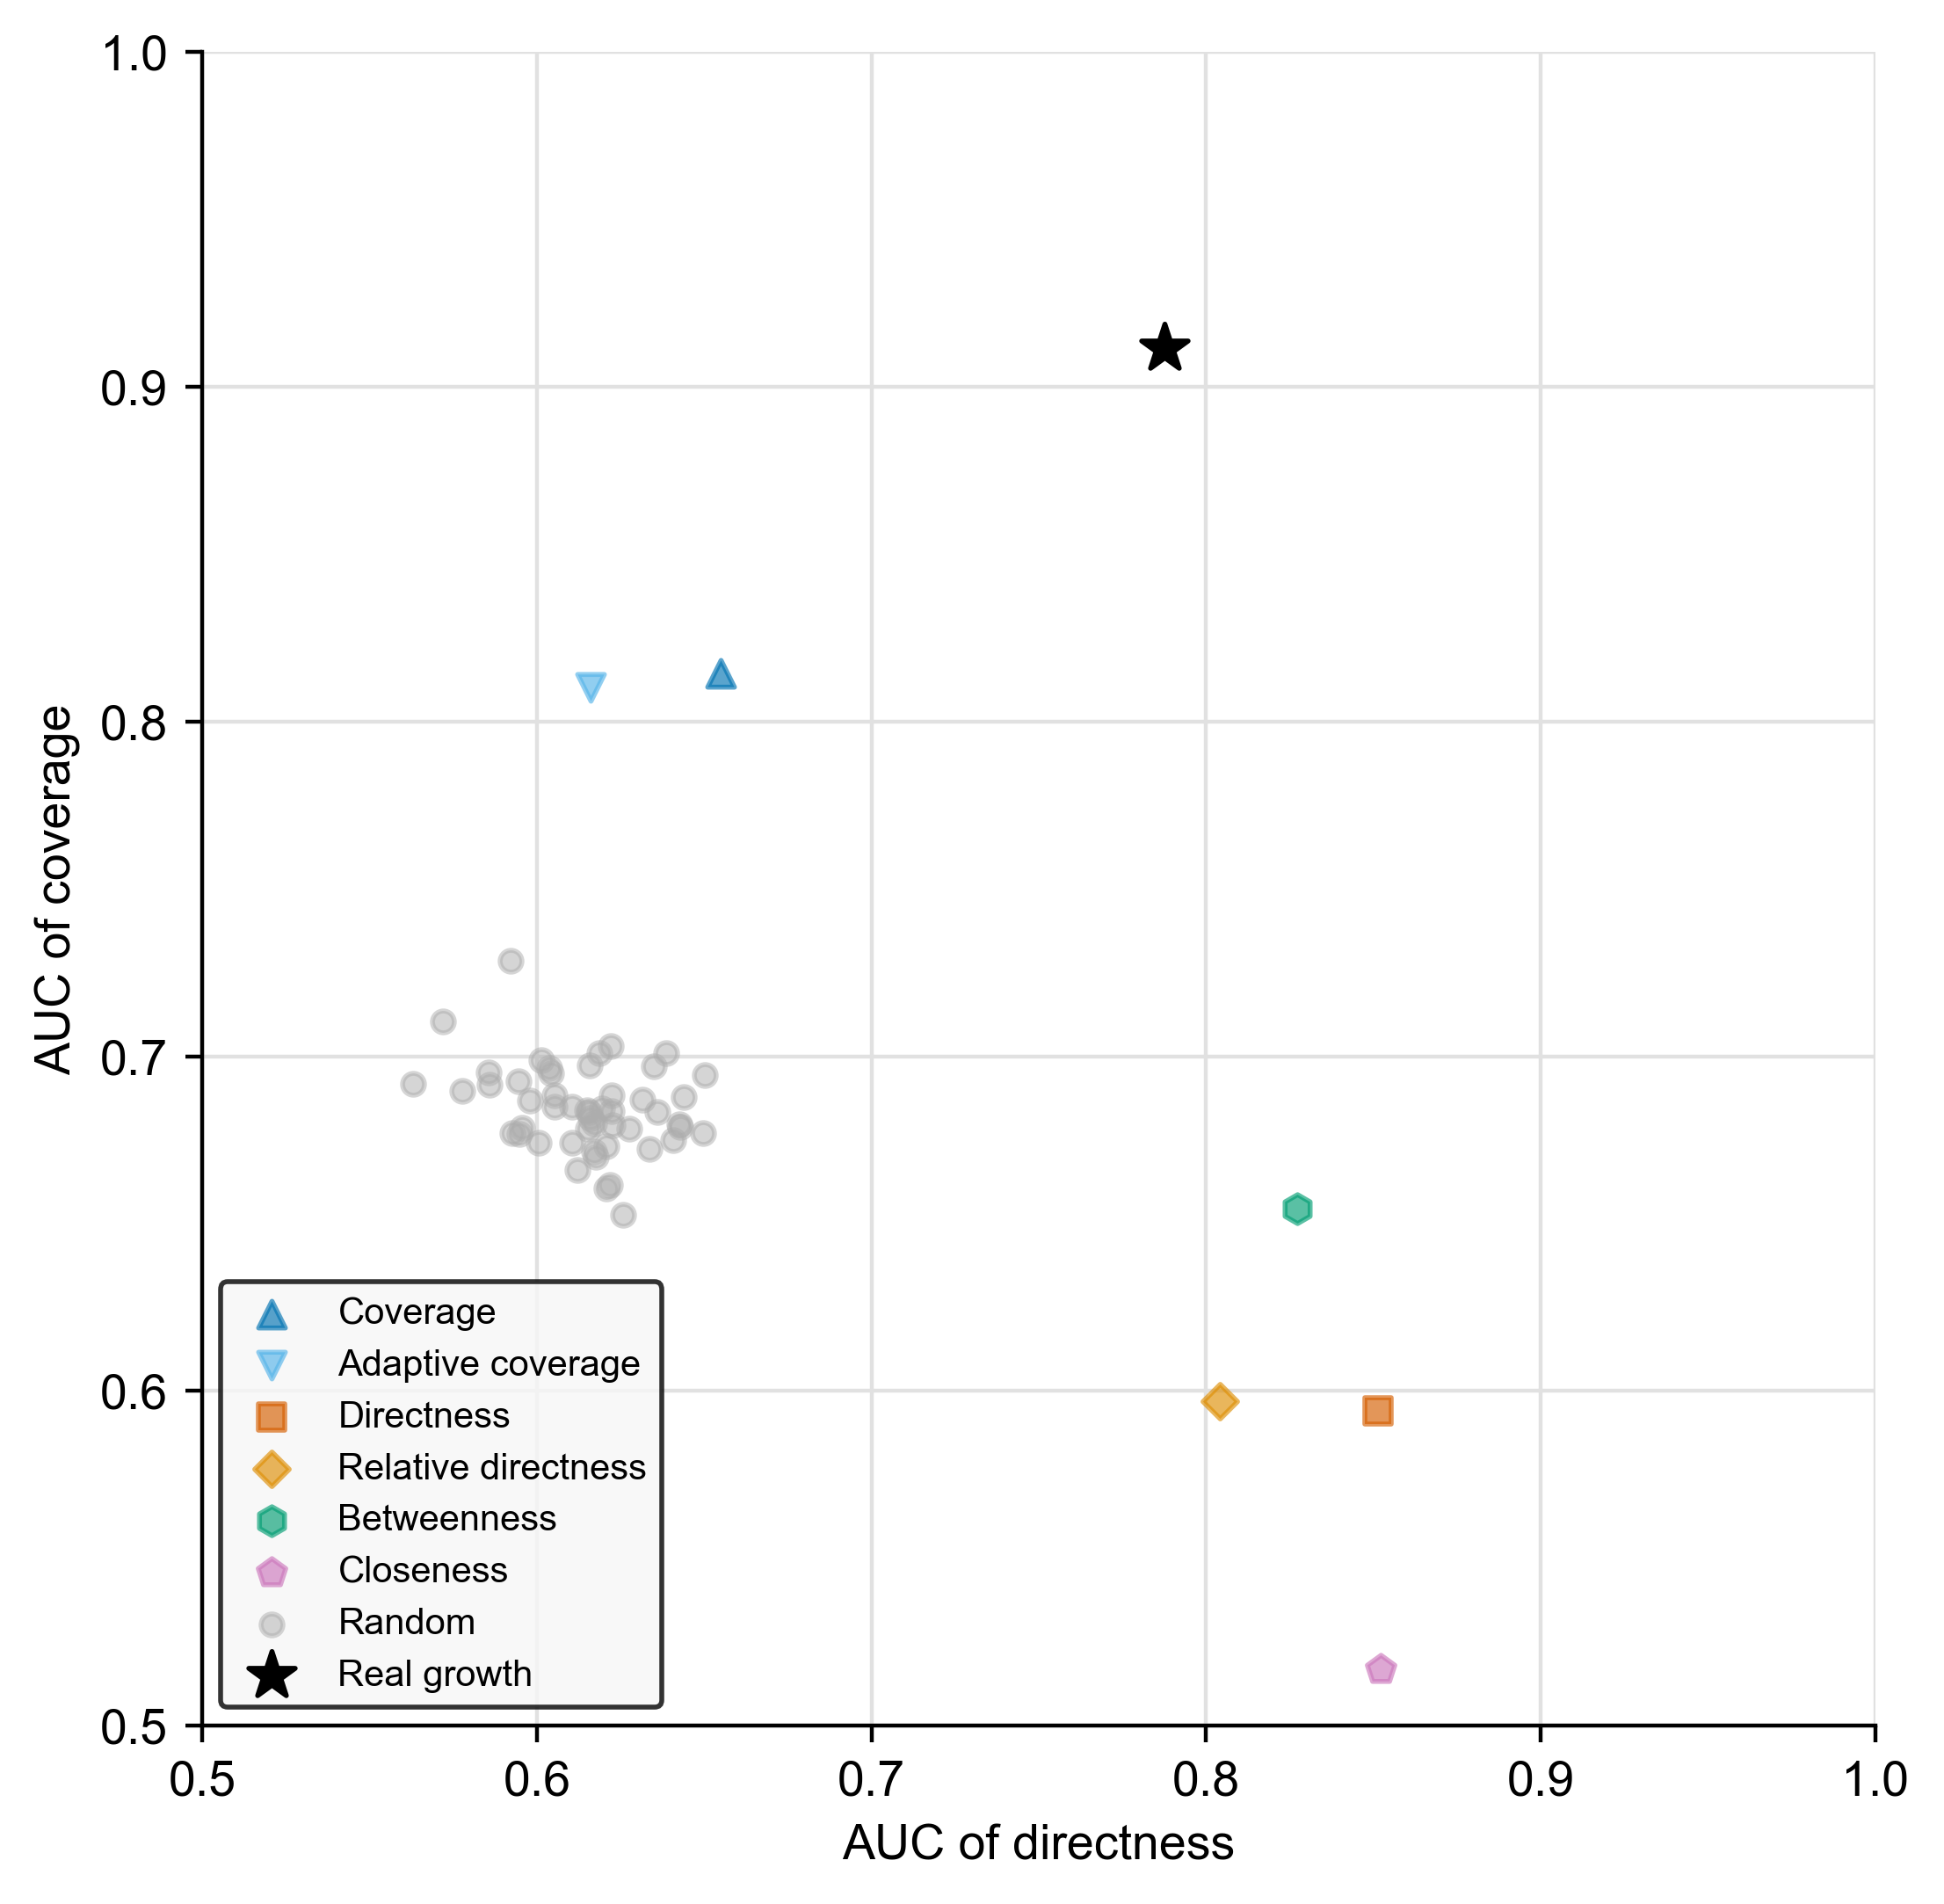

In [ ]:
for key in plot_params["rcparams"]:
    mpl.rcParams[key] = plot_params["rcparams"][key]
fig, ax = plt.subplots(figsize=plot_params["figsize"])
for ids, met in enumerate(plot_params["order"][:7]):
    if met == "random":
        auc_rand_covs = []
        auc_rand_dirs = []
        for i in range(50):
            with open(
                f"../data/processed/paris_simplified_results/Nothing/{met}_additive_connected/metrics_growth_{i:02}.json",
                "r",
            ) as f:
                met_dict = json.load(f)
            auc_rand_covs.append(
                auc_from_metrics_dict(
                    met_dict,
                    "coverage",
                    normalize_y=True,
                    yaxis_method="natural",
                    exp_discounting=False,
                )
            )
            auc_rand_dirs.append(
                auc_from_metrics_dict(
                    met_dict,
                    "directness",
                    normalize_y=False,
                    max_comparison_y="one",
                    exp_discounting=False,
                )
            )
        ax.scatter(
            auc_rand_dirs,
            auc_rand_covs,
            zorder=2,
            **{
                key: val[ids]
                for key, val in plot_params.items()
                if key
                not in [
                    "dpi",
                    "figsize",
                    "rcparams",
                    "order",
                    "errorbar",
                ]
            },
        )
    else:
        with open(
            f"../data/processed/paris_simplified_results/Nothing/{met}_additive_connected/metrics_growth.json",
            "r",
        ) as f:
            met_dict = json.load(f)
        ax.scatter(
            auc_from_metrics_dict(
                met_dict,
                "directness",
                normalize_y=False,
                max_comparison_y="one",
                exp_discounting=False,
            ),
            auc_from_metrics_dict(
                met_dict,
                "coverage",
                normalize_y=True,
                yaxis_method="natural",
                exp_discounting=False,
            ),
            zorder=2,
            **{
                key: val[ids]
                for key, val in plot_params.items()
                if key
                not in [
                    "dpi",
                    "figsize",
                    "rcparams",
                    "order",
                    "errorbar",
                ]
            },
        )
ax.scatter(
    get_auc(
        tot_length,
        directness,
        normalize_y=False,
        max_comparison_y="one",
        exp_discounting=False,
    ),
    get_auc(
        tot_length,
        coverage,
        normalize_y=True,
        yaxis_method="natural",
        exp_discounting=False,
    ),
    zorder=2,
    label="Real growth",
    color="black",
    marker="*",
    s=100,
)
ax.set_xlabel("AUC of directness")
ax.set_ylabel("AUC of coverage")
loc = mpl.ticker.MultipleLocator(base=0.1)
ax.xaxis.set_major_locator(loc)
ax.yaxis.set_major_locator(loc)
plt.axis("square")
# Set rounded limits at smallest and highest 0.1
mmin = 0.5
mmax = 1
ax.set_xlim([mmin, mmax])
ax.set_ylim([mmin, mmax])
plt.legend(prop={"size": plot_params["rcparams"]["font.size"] * 0.75})

In [104]:
print(
    get_auc(
        tot_length,
        directness,
        normalize_y=False,
        max_comparison_y="one",
        exp_discounting=False,
    ),
    get_auc(
        tot_length,
        coverage,
        normalize_y=True,
        yaxis_method="natural",
        exp_discounting=False,
    ),
)

0.7875899747766365 0.9115697320222846
